# Chinese Character Database — Analysis Notebook

**Author:** Robert W Cellucci  
**Project:** CJK (Chinese-Japanese-Korean) SQLite Character Database  

This notebook queries the pre-built `Chinese_Character_Database.db` and is **read-only** with respect to the database. The companion creation notebook builds the database from raw source files.

Every query in this notebook opens a connection wrapped in a `with` block — which manages the transaction (committing or rolling back) rather than closing the connection — enforces foreign key constraints with `PRAGMA foreign_keys = ON`, and reads results directly into a pandas DataFrame. Nothing is written back to disk.

## Analytical Narrative

Mandarin (China / Taiwan), Japanese, and Korean each maintain their own official character standards
for education and literacy. Yet all three draw from the same logographic pool. A
Japanese learner working through the Jōyō list, a Mandarin learner working through
HSK 3.0 or through Taiwan's Ministry of Education standard, and a
Korean learner working through the Korean Educational Hanja list are all engaging with
largely the same script with no published map of where those curricula actually overlap.

This notebook works toward one central finding: **which characters represent a
cross-validated, multi-institutional consensus on foundational Chinese character literacy?**

The sections below build toward that answer incrementally. Sections 1 and 2 characterize
Japan's lists in isolation, first identifying what Japan considers essential that no other
system shares, then tracing how Japan's traditional-form kanji relate to Mainland China's
simplification reforms. Sections 3 and 4 establish pairwise overlaps between Japan and its
East Asian neighbors. Section 5 delivers the core finding: the strict three-way intersection
of Japan, Taiwan, and Korea — **2,573 characters** independently ratified by three national
educational authorities.

## Section Map

| Section | Question | Source Lists Involved |
|---|---|---|
| **1** | Japan Exclusivity: which Japanese characters appear in no other regional list? | `Japan` |
| **2** | How characters from Japan's lists were simplified in China's script reforms | `Japan`, `trad_simp_map` |
| **3** | Japan ↔ Korea pairwise overlap | `Japan`, `Korea` |
| **4** | Japan ↔ Taiwan pairwise overlap | `Japan`, `Taiwan` |
| **5** | Pan-CJK three-way intersection: core finding | `Japan`, `Taiwan`, `Korea` |

---

## Import Statements

Only three top-level imports are needed:

- `pandas` — in-memory data wrangling and the staging layer for all query results
- `sqlite3` — Python's built-in SQLite driver; no installation required
- `matplotlib` - For some ending visualizations

In [16]:
import pandas as pd          
import sqlite3 as sql         
import matplotlib.pyplot as plt

## Configuration and Connection Helper

`DB_PATH` centralizes the database filename in one place instead of repeating the
literal string in every connection block. `run_query` wraps the connect / PRAGMA /
`read_sql_query` boilerplate that every subsequent cell needs — each call still opens
its own connection (SQLite connections are cheap and this keeps every query's `with`
block scope minimal), but the six lines of setup shrink to a single function call.


In [17]:
DB_PATH = 'Chinese_Character_Database.db'

def run_query(query, params=None):
    """Open a connection to DB_PATH, enforce foreign key constraints, run `query`,
    and return the result as a DataFrame. PRAGMA foreign_keys is reissued on every
    call because SQLite does not persist the setting outside the connection that
    set it."""
    with sql.connect(DB_PATH) as conn:
        conn.execute("PRAGMA foreign_keys = ON")
        return pd.read_sql_query(query, conn, params=params)


## Database Validation

Before running any analytical queries, it is worth confirming that the database is
structurally sound: all expected tables are present, row counts are plausible, and
foreign key relationships are intact. This section is a sanity check, not part of
the analysis proper but it catches silent corruption or a stale `.db` file early,
before a bad join produces a misleadingly empty result downstream.

In [18]:
# ── Database Validation ────────────────────────────────────────────────────────
#       Expected tables:
#         - character_table      (spine of the schema; one row per unique codepoint)
#         - character_source     (list membership: Joyo, Jinmeiyo, MoE, HSK, Hanja, etc.)
#         - dic_index_table  (entry numbers in KangXi, Morohashi, Nelson, etc.)
#         - trad_simp_map        (3,165 Traditional → Simplified codepoint pairs)

master_table = run_query("""
SELECT *
FROM sqlite_master
""")
display(master_table)


,type,name,tbl_name,rootpage,sql
0,table,character_table,character_table,2,CREATE TABLE character_table (\n codepo...
1,table,character_source,character_source,3,CREATE TABLE character_source (\n c...
2,index,sqlite_autoindex_character_source_1,character_source,5,NaN
3,table,dic_index_table,dic_index_table,4,CREATE TABLE dic_index_table (\n co...
4,table,trad_simp_map,trad_simp_map,6,CREATE TABLE trad_simp_map (\n trad_cod...
5,index,sqlite_autoindex_trad_simp_map_1,trad_simp_map,15,NaN


---

## The Japanese Primary Kanji List

Japan maintains two official kanji lists administered by the Ministry of Education:

- **Jōyō kanji** (常用漢字) — 2,136 characters designated for general use in newspapers,
  government documents, and public communication. These are the characters every student
  is expected to master by the end of compulsory education.
- **Jinmeiyō kanji** (人名用漢字) — 863 characters approved for use in personal names
  but not required for general literacy. They extend the usable character set for naming
  purposes beyond the Jōyō core.

Together these two lists define the full scope of officially sanctioned kanji in Japan.
The query below retrieves all 3,003 characters across both lists, which will serve as
the Japan-side operand for all subsequent comparisons.

In [19]:
japanese_characters = run_query("""
SELECT cs.codepoint, MIN(ct.literal) AS literal
FROM character_source AS cs
JOIN character_table AS ct
    ON cs.codepoint = ct.codepoint
WHERE (cs.source = 'Joyo' OR cs.source = 'Jinmeiyo')
GROUP BY cs.codepoint
""")

display(japanese_characters)   # Expected: 2,999 rows


,codepoint,literal
0,19968,一
1,19969,丁
2,19971,七
3,19975,万
4,19976,丈
...,...,...
2994,64101,贈
2995,64103,逸
2996,64104,難
2997,64105,響


### Characters Exclusive to Japan

Of Japan's 2,999 kanji, how many appear on no other regional educational list?
The query below uses a `NOT EXISTS` correlated subquery to filter to codepoints
that have a source row for Japan but no source row for any other region. These
are characters that Japan's curriculum considers essential but that Taiwan's MoE,
Korea's Educational Hanja list, and China's HSK 3.0 all omit.

The result is **267 characters** that includes a significant proportion of Jinmeiyō
kanji (name-use characters with limited general circulation) and a smaller number
of Jōyō kanji that have no clear cognate in other CJK educational frameworks.

In [20]:
japan_exclusive = run_query("""
    SELECT
        cs.codepoint,
        ct.literal
    FROM character_source AS cs
    JOIN character_table AS ct
        ON cs.codepoint = ct.codepoint
    WHERE (cs.source = 'Joyo' OR cs.source = 'Jinmeiyo')
    AND NOT EXISTS (
          -- Exclude any codepoint that has a source row outside Japan
          SELECT 1
          FROM character_source AS cs2
          WHERE cs2.codepoint = cs.codepoint
            AND cs2.source_region != 'Japan'
      )
    ORDER BY cs.codepoint
""")

display(japan_exclusive)   # Expected: 267 rows


,codepoint,literal
0,20001,両
1,20028,丼
2,20055,乗
3,20096,亀
4,20175,仏
...,...,...
262,64101,贈
263,64103,逸
264,64104,難
265,64105,響


### A Note About Kokuji

**Kokuji** (国字, literally "country characters") are kanji invented in Japan. These characters
have no Chinese etymological origin and exist only in the Japanese writing system.
Well-known examples include 働 (*hataraku*, to work) and 峠 (*tōge*, mountain pass).

Because kokuji were never part of the Chinese character pool, they are by definition
absent from Taiwan's MoE list, Korea's Hanja list, and China's HSK. This makes them a
structural subset of the Japan-exclusive set identified in Section 1a. 

Note: Not all the characters that are unique to Japan here are kokuji, by Wikipedia's estimate there should only be 16 kokuji in Japan's national lists.


## How Japan's Kanji Were Simplified in Mainland China

Japan and Mainland China both reformed their official character sets in the twentieth
century, independently simplifying stroke structures that had remained stable for
centuries. The reforms took different forms including Japan's Jōyō revisions (1946, 1981, 2010)
produced *shinjitai* (新字体) variants; China's reforms (1956, 1964) produced *simplified
characters* (简体字) and the two systems did not coordinate. The result is a complex
mapping where some Japanese and Chinese forms converge on the same simplified shape,
others diverge, and some characters were simplified in only one system.

The `trad_simp_map` table records 3,165 explicit Traditional-to-Simplified codepoint
pairs, derived from the HSK 3.0 dataset. The query below joins Japan's Jōyō list
against this map to surface the **463 Jōyō kanji** that have a recorded Mainland
Chinese simplified counterpart displaying both the traditional form (as used in
Japan) and the simplified form (as used in the PRC) side by side.

Note that this query is scoped to Jōyō only (not Jinmeiyō), since Jinmeiyō characters
are unlikely to appear in HSK-derived simplification data.

In [21]:
j_simp = run_query("""
SELECT 
    map.trad_codepoint,   -- Codepoint of the traditional form (as used in Japan)
    map.trad_literal,     -- Traditional character glyph
    map.simp_codepoint,   -- Codepoint of the Mainland Chinese simplified form
    map.simp_literal      -- Simplified character glyph
FROM character_source AS cs
    JOIN trad_simp_map AS map 
    ON cs.codepoint = map.trad_codepoint   -- Match Joyo codepoints to their traditional-form entry in the map
WHERE cs.source = 'Joyo'                   -- Scoped to Joyo only; Jinmeiyo excluded
ORDER BY cs.codepoint
""")

display(j_simp)   # Expected: 463 rows


,trad_codepoint,trad_literal,simp_codepoint,simp_literal
0,20006,並,24182,并
1,20094,乾,24178,干
2,20341,併,24182,并
3,20406,侶,20387,侣
4,20418,係,31995,系
...,...,...,...,...
458,39854,鮮,40092,鲜
459,40165,鳥,40479,鸟
460,40180,鳴,40483,鸣
461,40372,鶴,40548,鹤


## Japan ↔ Korea Pairwise Overlap

Korea's Educational Hanja list (한문 교육용 기초 한자) designates 1,800 characters for
instruction in middle and high school. Like Japan's kanji system, Korean Hanja are
traditional-form characters, the same script pool that predates both Japan's shinjitai
reforms and China's simplification program. This shared traditional-form heritage makes
Japan-Korea overlap comparisons methodologically cleaner than any comparison involving
China's simplified forms.

The query below identifies all codepoints that appear in at least one Japanese source
(Jōyō or Jinmeiyō) **and** in the Korean Educational Hanja list. The `HAVING` clause
enforces that both regions are represented, not just that a character appears in some
source from each region, but that both `source_region` values are present for that
codepoint. The `source_count` column reflects the number of *individual lists* (not
regions) a character belongs to, and will exceed 2 for characters present in both
Jōyō and Jinmeiyō simultaneously.

Result: **2,904 characters** which is the largest pairwise overlap between any two individual
national lists in this dataset.

In [22]:
j_k_full = run_query("""
    SELECT
        cs.codepoint, 
        ct.literal,
        COUNT(DISTINCT cs.source) AS source_count   -- Number of individual lists (Joyo, Jinmeiyo, Hanja, etc.)
    FROM character_source AS cs
    JOIN character_table AS ct
        ON cs.codepoint = ct.codepoint
    WHERE cs.source_region IN ('Korea', 'Japan')    -- Filter to only Japanese and Korean source rows
    GROUP BY cs.codepoint, ct.literal
    HAVING COUNT(DISTINCT cs.source_region) = 2    -- Strict intersection: both regions must be present
    ORDER BY cs.codepoint
""")

display(j_k_full)   # Expected: 2,904 rows


,codepoint,literal,source_count
0,19968,一,4
1,19969,丁,4
2,19971,七,4
3,19975,万,4
4,19976,丈,4
...,...,...,...
2899,40766,鼾,3
2900,40778,齊,2
2901,40799,齟,2
2902,40812,齬,2


## Japan ↔ Taiwan Pairwise Overlap

Taiwan's Ministry of Education list (國語常用字表) designates 4,808 characters for
standard Mandarin literacy instruction. Like Korea's Hanja list, it operates entirely
in traditional forms, the script Japan also uses, prior to any shinjitai substitutions.
The Taiwan list is the largest of the four regional lists in this database, which
makes it a generous comparator: nearly any character Japan teaches has a reasonable
chance of appearing in Taiwan's broader inventory.

The query structure is identical to Section 3, with `source_region` filtered to
`Japan` and `Taiwan` instead. The `HAVING COUNT(DISTINCT cs.source_region) = 2`
clause again enforces strict bilateral membership.

Result: **2,599 characters** shared between Japan's combined kanji lists and Taiwan's
MoE standard, a slightly smaller overlap than Japan-Korea, despite Taiwan's list
being considerably larger. This reflects the influence of Japan's shinjitai variants,
which introduced codepoint-level divergences from the traditional forms Taiwan continues
to use.

In [23]:
j_t_full = run_query("""
    SELECT
        cs.codepoint,
        ct.literal,
        COUNT(DISTINCT cs.source) AS source_count   
    FROM character_source AS cs 
    JOIN character_table AS ct
        ON cs.codepoint = ct.codepoint
    WHERE cs.source_region IN ('Taiwan', 'Japan')  
    GROUP BY cs.codepoint, ct.literal
    HAVING COUNT(DISTINCT cs.source_region) = 2   
    ORDER BY cs.codepoint
""")

display(j_t_full)   # Expected: 2,599 rows


,codepoint,literal,source_count
0,19968,一,4
1,19969,丁,4
2,19971,七,4
3,19976,丈,4
4,19977,三,4
...,...,...,...
2594,40766,鼾,3
2595,40778,齊,2
2596,40799,齟,2
2597,40812,齬,2


## Core Finding: The Pan-CJK Three-Way Intersection

The query below is the analytical destination of the entire notebook. It asks a
single question: **which characters appear on all three of Japan's Jōyō list,
Taiwan's Ministry of Education standard, and Korea's Educational Hanja list
simultaneously?**

The answer is **2573 characters**. This is a set that has been independently ratified
by three distinct national educational authorities, across three languages, over
decades of curriculum revision. No single institution designed this overlap; it
emerged from convergent pedagogical judgment about what logographic literacy
requires.

**Why these three lists, and not China (HSK)?**  
HSK 3.0 is represented in this database in its traditional character forms
(`hsk_trad`), not the simplified forms actually used in PRC classrooms. Including
it in the intersection would compare traditional-form proxies against the genuine
traditional-script standards of Japan, Taiwan, and Korea which would be a methodologically
unsound equivalence. China's data is used in cross-regional comparisons where the
comparison is directionally informative, but it is excluded from the core
intersection for this reason. The 2573-character set therefore represents the
consensus of the three living traditional-character educational systems, untainted
by the simplification asymmetry.

The `HAVING COUNT(DISTINCT cs.source_region) = 3` clause is what actually enforces
the strict three-way intersection here — every returned row is required to have all
three regions present before it can appear at all. A `source_count` column built the
same way as that `HAVING` clause would just restate the filter that already produced
the rows, so it's left out of the query below.


In [24]:
j_t_k_full = run_query("""
    SELECT
        cs.codepoint,
        ct.literal
    FROM character_source AS cs
    JOIN character_table AS ct
        ON cs.codepoint = ct.codepoint
    WHERE cs.source_region IN ('Japan', 'Taiwan', 'Korea')  
    GROUP BY cs.codepoint, ct.literal
    HAVING COUNT(DISTINCT cs.source_region) = 3            
    ORDER BY cs.codepoint
""")
    
display(j_t_k_full)   # Expected: 2573 rows

,codepoint,literal
0,19968,一
1,19969,丁
2,19971,七
3,19976,丈
4,19977,三
...,...,...
2568,40766,鼾
2569,40778,齊
2570,40799,齟
2571,40812,齬


In [25]:
sources = run_query("""
    SELECT source, source_region, COUNT(DISTINCT codepoint) AS number
    FROM character_source
    GROUP BY source, source_region
    ORDER BY source_region, source
""")
display(sources)


,source,source_region,number
0,hsk_simp,China,2999
1,hsk_trad,China,3164
2,Jinmeiyo,Japan,863
3,Joyo,Japan,2136
4,RememberingTheKanji5th,Japan,3030
5,RememberingTheKanji6th,Japan,3000
6,KoreanEducationHanja,Korea,1800
7,KoreanName,Korea,6367
8,TaiwanEducationHanzi,Taiwan,4808


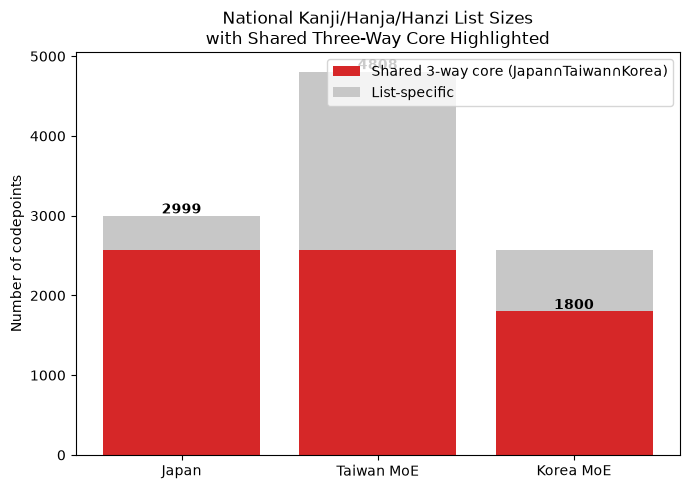

In [30]:
totals = {
    'Japan': 2999,
    'Taiwan MoE': 4808,   # from the query above
    'Korea MoE': 1800,
}
three_way_core = 2573  # Japan ∩ Taiwan ∩ Korea

countries = list(totals.keys())
total_vals = list(totals.values())


core_vals = [three_way_core if c in ('Japan', 'Taiwan MoE', 'Korea MoE') else 0 for c in countries]
remainder_vals = [t - c for t, c in zip(total_vals, core_vals)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(countries, core_vals, label='Shared 3-way core (Japan∩Taiwan∩Korea)', color='#d62728')
ax.bar(countries, remainder_vals, bottom=core_vals, label='List-specific', color='#c7c7c7')

for i, t in enumerate(total_vals):
    ax.text(i, t + 30, str(t), ha='center', fontweight='bold')

ax.set_ylabel('Number of codepoints')
ax.set_title('National Kanji/Hanja/Hanzi List Sizes\nwith Shared Three-Way Core Highlighted')
ax.legend()
plt.tight_layout()
plt.show()

## Window-Function View of the Three-Way Composition

The pairwise and three-way queries above establish overlap one relationship at a
time. The query below computes the full decomposition in a single pass — for
each region, how many of its characters are exclusive, shared with exactly one
other region, or shared with both — and its output feeds the stacked-bar chart
directly, replacing the pandas set-arithmetic version used earlier in
development.

Two things worth understanding well enough to explain in an interview:

**The first window function counts regions per character and carries that value
onto every row for that character.** `COUNT(*) OVER (PARTITION BY codepoint)` in
the `tiered` CTE does not collapse rows the way a `GROUP BY` would. Instead, for
each codepoint it counts how many region rows exist and attaches that same count
to *every* row belonging to that codepoint. A character present in Japan,
Taiwan, and Korea gets `n_regions = 3` on all three of its rows; a character
present in Japan alone gets `n_regions = 1` on its single row. This is what lets
the outer `GROUP BY source_region, n_regions` bucket every character into an
exclusive / shared-by-two / shared-by-three tier per region.

**The second nests an aggregate inside a window function** —
`SUM(COUNT(*)) OVER (PARTITION BY source_region)` — to get each tier's share of
its own region's list. `COUNT(*)` first collapses each `(source_region,
n_regions)` group down to a row count; the outer `SUM(...) OVER (PARTITION BY
source_region)` then re-expands that, summing across all three tiers within a
region to recover that region's grand total, without a second query or a
self-join. Dividing the group's count by that windowed sum gives the percentage
of the region's list each tier represents.

The finding this produces is arguably more interesting than the raw
intersection: Taiwan's 4,808-character list turns out to be mostly *not* shared
with Japan or Korea, which reframes the three-way core as a genuine convergence
rather than an artifact of one oversized list swallowing the other two.


In [27]:
tiered_query = """
WITH region_membership AS (
    SELECT DISTINCT codepoint, source_region
    FROM character_source
    WHERE source_region IN ('Japan', 'Taiwan', 'Korea')
),
tiered AS (
    SELECT
        codepoint,
        source_region,
        COUNT(*) OVER (PARTITION BY codepoint) AS n_regions
    FROM region_membership
)
SELECT
    source_region,
    n_regions,
    COUNT(*) AS chars,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY source_region), 1) AS pct_of_region
FROM tiered
GROUP BY source_region, n_regions
ORDER BY source_region, n_regions
"""

tiered_result = run_query(tiered_query)
display(tiered_result)

# Reshape into the exclusive / shared_by_two / shared_by_three columns the chart below expects
tier_labels = {1: 'exclusive', 2: 'shared_by_two', 3: 'shared_by_three'}
tiered_result['tier'] = tiered_result['n_regions'].map(tier_labels)

decomp = (
    tiered_result
    .pivot(index='source_region', columns='tier', values='chars')
    .fillna(0)
    .astype(int)
    .rename_axis('region')
    [['exclusive', 'shared_by_two', 'shared_by_three']]
)
display(decomp)


,source_region,n_regions,chars,pct_of_region
0,Japan,1,395,11.9
1,Japan,2,357,10.7
2,Japan,3,2573,77.4
3,Korea,1,3394,41.9
4,Korea,2,2127,26.3
5,Korea,3,2573,31.8
6,Taiwan,1,413,8.6
7,Taiwan,2,1822,37.9
8,Taiwan,3,2573,53.5


tier,exclusive,shared_by_two,shared_by_three
region,,,
Japan,395,357,2573
Korea,3394,2127,2573
Taiwan,413,1822,2573


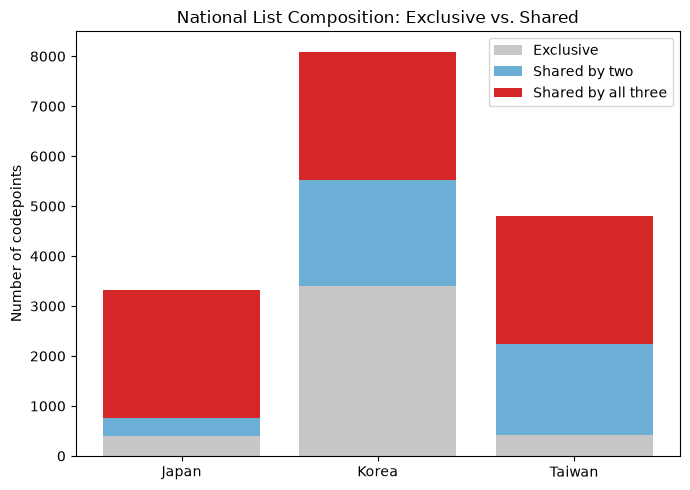

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
bottom = [0, 0, 0]
colors = {'exclusive': '#c7c7c7', 'shared_by_two': '#6baed6', 'shared_by_three': '#d62728'}
labels = {'exclusive': 'Exclusive', 'shared_by_two': 'Shared by two', 'shared_by_three': 'Shared by all three'}

for col in ['exclusive', 'shared_by_two', 'shared_by_three']:
    ax.bar(decomp.index, decomp[col], bottom=bottom, label=labels[col], color=colors[col])
    bottom = [b + v for b, v in zip(bottom, decomp[col])]

ax.set_ylabel('Number of codepoints')
ax.set_title('National List Composition: Exclusive vs. Shared')
ax.legend()
plt.tight_layout()
plt.show()

# Conclusion

This notebook set out to answer one question: which characters represent a genuine, independently-arrived-at consensus across the three living traditional-character educational systems? The answer is the **2,573-character** intersection of Japan's Jōyō/Jinmeiyō lists, Taiwan's Ministry of Education standard, and Korea's Educational Hanja list — a set no single authority designed, but one that all three converged on through separate curriculum decisions.

The window-function decomposition adds an important qualifier to that headline number: Taiwan's list, at 4,808 characters, is the largest of the three by a wide margin, and the tiered breakdown shows most of it is *not* shared with Japan or Korea. That matters for how the 2,573-character core should be read — it isn't the product of one oversized list absorbing two smaller ones, but a comparatively narrow band of agreement carved out of substantially different national inventories. That framing is why the pairwise figures (Japan∩Korea = 2,904; Japan∩Taiwan = 2,599) look large in isolation but shrink considerably once all three lists have to agree simultaneously.

China's HSK data was intentionally left out of this core intersection. As discussed in Section 2, `hsk_trad` reflects traditional-form proxies rather than the simplified characters actually taught in PRC classrooms, so folding it into a strict three-way comparison against genuinely traditional-script standards would have been a methodologically unsound equivalence. Where China's data does appear — the Jōyō-to-simplified mapping in Section 2 — it's used descriptively, not as a fourth operand in the core intersection.

Taken together, the sections above move from characterizing Japan's lists in isolation, to pairwise comparisons with its neighbors, to the strict three-way core, to a structural view of how much of each region's list that core actually represents. The known limitations below qualify how much weight the resulting numbers can bear.

### Known Limitations

**Han Unification overcounts true overlap.** Unicode merged visually similar CJK
characters into single codepoints. Characters that are functionally distinct across
regions but share a codepoint due to glyph unification are counted as one, inflating
apparent overlap between scripts. Regional glyph variation and simplification schemes
are not captured by the Unihan data alone.

**HSK is represented in traditional forms only.** The `hsk_trad` source contains
traditional written forms of HSK 3.0 vocabulary, not the simplified forms used in
PRC classrooms. Cross-script comparisons involving China reflect traditional
character inventories, which are no longer the characters Mainland learners actually study.